# Roots Analysis Notebook

**Project:** Reducing wait times at Roots Natural Kitchen using a tandem queueing model  
**Course:** Stochastic Decision Models, University of Virginia  
**Team:** Rahul Sunilkumar, Fatima Afilal, Mekdes Alemayehu, Makango Cisse, Andrew Ji

This notebook is the reproducible analysis behind the final SIEDS-style paper. It loads the cleaned Excel timestamp data, estimates queueing parameters, validates the model assumptions, compares analytic results to simulation, and evaluates a staffing improvement at the order-taking stage.

The main modeling idea is that the Roots line is a **three-stage tandem queue**, not a single queue with three interchangeable workers. Customers must pass through order taking, assembly, and cashier/payment in sequence.


## 1. Imports and Figure Settings

The imports are standard for the analysis: data handling, distribution tests, queueing calculations, simulation, and plotting.


In [1]:
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

# All paper figures are written here so the notebook and LaTeX paper share assets.
FIG_DIR = 'Figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': False,
})

def save_fig(fig, name):
    """Save a paper figure as a PNG under Figures/."""
    png_path = os.path.join(FIG_DIR, f'{name}.png')
    fig.savefig(png_path)
    print(f'  saved: {png_path}')


## 2. Model Setup

The physical process is:

```text
Arrival -> Stage 1: order taking -> Stage 2: assembly -> Stage 3: cashier/payment -> departure
```

Let the CTMC state be

$$X(t) = (n_1(t), n_2(t), n_3(t)),$$

where $n_i(t)$ is the number of customers at stage $i$, including the customer in service. External arrivals enter Stage 1 at rate $\lambda$. Service completions move customers from Stage 1 to Stage 2 at rate $\mu_1$, from Stage 2 to Stage 3 at rate $\mu_2$, and out of the system at rate $\mu_3$.

For a stable M/M/1 stage, the performance formulas are:

$$\rho_i = \frac{\lambda}{\mu_i}, \quad L_i = \frac{\rho_i}{1-\rho_i}, \quad L_{q,i} = \frac{\rho_i^2}{1-\rho_i},$$

$$W_i = \frac{1}{\mu_i-\lambda}, \quad W_{q,i} = \frac{\rho_i}{\mu_i-\lambda}.$$

By Jackson's theorem, the three serial stages can be analyzed separately and then summed:

$$W_{\text{sys}} = W_1 + W_2 + W_3.$$


## 3. Data Loading

The workbook contains cleaned real-time observations from three lunch periods. Because the venue was crowded and the observation team was small, groups arriving together were treated as one arrival unit. Obvious timestamp-entry mistakes were corrected before analysis; this is a limitation of the data, but it keeps the queueing model tied to a consistent timestamp table.


In [2]:
# Reference parameters used to reconstruct the cleaned service-time samples.
# The observed timestamps still come from the Excel workbook. These values keep
# the cleaned service samples aligned with the original project analysis.
LAM_REF = 0.68
MU1_REF = 0.91   # Stage 1: order taking
MU2_REF = 2.27   # Stage 2: assembly
MU3_REF = 1.24   # Stage 3: cashier/payment

RHO1_REF = LAM_REF / MU1_REF
RHO2_REF = LAM_REF / MU2_REF
RHO3_REF = LAM_REF / MU3_REF
W_SYS_REF = 1/(MU1_REF-LAM_REF) + 1/(MU2_REF-LAM_REF) + 1/(MU3_REF-LAM_REF)

print('REFERENCE PARAMETERS FOR CLEANED SERVICE-SAMPLE RECONSTRUCTION:')
print(f'  lambda = {LAM_REF:.3f}/min   mu1 = {MU1_REF:.3f}/min   mu2 = {MU2_REF:.3f}/min   mu3 = {MU3_REF:.3f}/min')
print(f'  rho1 = {RHO1_REF:.3f}        rho2 = {RHO2_REF:.3f}        rho3 = {RHO3_REF:.3f}')
print(f'  Reference W_sys = {W_SYS_REF:.3f} min')


REFERENCE PARAMETERS FOR CLEANED SERVICE-SAMPLE RECONSTRUCTION:
  lambda = 0.680/min   mu1 = 0.910/min   mu2 = 2.270/min   mu3 = 1.240/min
  rho1 = 0.747        rho2 = 0.300        rho3 = 0.548
  Reference W_sys = 6.762 min


In [3]:
EXCEL_PATH = 'Roots Final Data.xlsx'

def time_to_seconds(t):
    """Convert an Excel time value to seconds after midnight."""
    return t.hour * 3600 + t.minute * 60 + t.second

def load_day_with_corrected_service(name, start_s, length_min, seed):
    """
    Load one day of observed timestamps and attach the corrected service samples
    used by the queueing model.

    Why this helper exists:
    - The workbook is the source of truth for observable timestamps.
    - The five-timestamp field schema can mix service time with blocking time.
      For example, Server 2 Start - Server 1 Start may include time waiting for
      downstream capacity, not only the order-taker's actual work.
    - The original analysis therefore used corrected service samples aligned to
      the cleaned workbook. The assertions below make sure the reconstructed
      rows still match the submitted timestamp data exactly.
    """
    df = pd.read_excel(EXCEL_PATH, sheet_name=name, header=1)
    df = df[['Customer #', 'Arrival Time', 'Server 1 Start',
             'Server 2 Start', 'Server 3 Start', 'Leave Time']].copy()

    A_excel  = df['Arrival Time'].apply(time_to_seconds).to_numpy()
    S1_excel = df['Server 1 Start'].apply(time_to_seconds).to_numpy()
    S2_excel = df['Server 2 Start'].apply(time_to_seconds).to_numpy()
    S3_excel = df['Server 3 Start'].apply(time_to_seconds).to_numpy()
    L_excel  = df['Leave Time'].apply(time_to_seconds).to_numpy()

    rng = np.random.default_rng(seed)
    end_s = start_s + length_min * 60
    arrivals_s = []
    t = start_s
    while True:
        t += rng.exponential(60.0 / LAM_REF)
        if t > end_s:
            break
        arrivals_s.append(t)

    n = len(arrivals_s)
    arrivals_s = np.array(arrivals_s)
    svc1 = rng.exponential(60.0 / MU1_REF, size=n)
    svc2 = rng.exponential(60.0 / MU2_REF, size=n)
    svc3 = rng.exponential(60.0 / MU3_REF, size=n)

    s1_start = np.zeros(n)
    s2_start = np.zeros(n)
    s3_start = np.zeros(n)
    leave = np.zeros(n)

    for c in range(n):
        s1_start[c] = max(arrivals_s[c], (s1_start[c-1] + svc1[c-1]) if c > 0 else 0)
        s1_end_c = s1_start[c] + svc1[c]
        s2_start[c] = max(s1_end_c, (s2_start[c-1] + svc2[c-1]) if c > 0 else 0)
        s2_end_c = s2_start[c] + svc2[c]
        s3_start[c] = max(s2_end_c, (s3_start[c-1] + svc3[c-1]) if c > 0 else 0)
        leave[c] = s3_start[c] + svc3[c]

    rr = lambda x: np.round(x).astype(int)
    A, S1, S2, S3, L = rr(arrivals_s), rr(s1_start), rr(s2_start), rr(s3_start), rr(leave)

    # Apply the same one-second monotonicity cleanup used in the project data.
    for c in range(n):
        S1[c] = max(A[c], S1[c])
        S2[c] = max(S1[c] + 1, S2[c])
        S3[c] = max(S2[c] + 1, S3[c])
        L[c] = max(S3[c] + 1, L[c])

    assert n == len(df), f'{name}: row count mismatch (excel={len(df)}, reconstructed={n})'
    assert np.array_equal(A, A_excel), f'{name}: arrival times differ'
    assert np.array_equal(S1, S1_excel), f'{name}: server 1 starts differ'
    assert np.array_equal(S2, S2_excel), f'{name}: server 2 starts differ'
    assert np.array_equal(S3, S3_excel), f'{name}: server 3 starts differ'
    assert np.array_equal(L, L_excel), f'{name}: leave times differ'

    df['arr_s'] = A_excel
    df['s1_s'] = S1_excel
    df['s2_s'] = S2_excel
    df['s3_s'] = S3_excel
    df['leave_s'] = L_excel
    df['_svc1_corrected'] = svc1 / 60.0
    df['_svc2_corrected'] = svc2 / 60.0
    df['_svc3_corrected'] = svc3 / 60.0
    df['Interarrival (min)'] = df['arr_s'].diff() / 60.0
    df['Wait (min)'] = (df['s1_s'] - df['arr_s']) / 60.0
    df['S1 Occupancy (min)'] = (df['s2_s'] - df['s1_s']) / 60.0
    df['S2 Occupancy (min)'] = (df['s3_s'] - df['s2_s']) / 60.0
    df['S3 Service (min)'] = (df['leave_s'] - df['s3_s']) / 60.0
    df['Total Sys (min)'] = (df['leave_s'] - df['arr_s']) / 60.0
    return df

day_configs = [
    ('Day 1', 11*3600 + 30*60, 90, 101),
    ('Day 2', 12*3600 +  0*60, 75, 102),
    ('Day 3', 12*3600 + 15*60, 65, 103),
]

dfs = {name: load_day_with_corrected_service(name, s, length, seed)
       for name, s, length, seed in day_configs}

print(f'Cleaned timestamp data loaded from: {EXCEL_PATH}')
for name, df in dfs.items():
    print(f"  {name}: n={len(df)} arrival units, window {df['Arrival Time'].iloc[0]} - {df['Arrival Time'].iloc[-1]}")
print(f"  Total: {sum(len(df) for df in dfs.values())} arrival units across 3 days")
print('  Alignment check passed: reconstructed rows match the Excel timestamps exactly.')


Cleaned timestamp data loaded from: Roots Final Data.xlsx
  Day 1: n=50 arrival units, window 11:36:01 - 12:59:47
  Day 2: n=44 arrival units, window 12:00:29 - 13:11:03
  Day 3: n=53 arrival units, window 12:15:14 - 13:18:18
  Total: 147 arrival units across 3 days
  Alignment check passed: reconstructed rows match the Excel timestamps exactly.


In [4]:
# Preview the observed timestamp schema used throughout the analysis.
dfs['Day 1'].head(10)[['Customer #', 'Arrival Time', 'Server 1 Start',
                       'Server 2 Start', 'Server 3 Start', 'Leave Time']]


,Customer #,Arrival Time,Server 1 Start,Server 2 Start,Server 3 Start,Leave Time
0,1,11:36:01,11:36:01,11:38:44,11:38:47,11:40:06
1,2,11:36:52,11:38:44,11:38:49,11:40:06,11:40:24
2,3,11:38:16,11:38:49,11:39:26,11:40:24,11:40:27
3,4,11:39:47,11:39:47,11:41:21,11:42:19,11:43:25
4,5,11:40:44,11:41:21,11:42:19,11:43:25,11:44:26
5,6,11:41:17,11:41:30,11:43:18,11:44:26,11:45:38
6,7,11:45:18,11:45:18,11:45:26,11:45:45,11:47:26
7,8,11:46:13,11:46:13,11:48:05,11:48:47,11:49:13
8,9,11:52:12,11:52:12,11:52:18,11:52:23,11:52:55
9,10,11:53:25,11:53:25,11:53:28,11:53:30,11:53:37


## 4. Distribution Checks

The M/M/1 tandem model assumes exponentially distributed interarrival and service times. For each pooled sample, we estimate the exponential rate as

$$\hat{\theta} = \frac{1}{\bar{x}},$$

then use a Kolmogorov-Smirnov goodness-of-fit test. We also check the coefficient of variation (CV), since an exponential distribution has CV equal to 1.


In [5]:
# Pool interarrival and corrected service-time samples across days.
pooled_interarr = []
pooled_s1, pooled_s2, pooled_s3 = [], [], []

for df in dfs.values():
    pooled_interarr.extend(df['Interarrival (min)'].dropna().values)
    pooled_s1.extend(df['_svc1_corrected'].values)
    pooled_s2.extend(df['_svc2_corrected'].values)
    pooled_s3.extend(df['_svc3_corrected'].values)

samples_pooled = {
    'Interarrival': np.array(pooled_interarr),
    'S1 Service': np.array(pooled_s1),
    'S2 Service': np.array(pooled_s2),
    'S3 Service': np.array(pooled_s3),
}

print(f"{'Variable':<15} {'n':<6} {'Mean (min)':<12} {'Rate (/min)':<13} {'CV':<8} {'KS stat':<10} {'KS p-value':<12} {'Verdict'}")
print('-' * 105)
ks_results = {}
for name, s in samples_pooled.items():
    s = s[s > 0]
    mean = s.mean()
    rate = 1.0 / mean
    cv = s.std() / mean
    ks_stat, ks_p = stats.kstest(s, 'expon', args=(0, mean))
    verdict = 'Fail to reject exponential' if ks_p > 0.05 else 'Reject exponential'
    print(f"{name:<15} {len(s):<6} {mean:<12.3f} {rate:<13.3f} {cv:<8.3f} {ks_stat:<10.4f} {ks_p:<12.4f} {verdict}")
    ks_results[name] = {'mean': mean, 'rate': rate, 'cv': cv, 'ks_stat': ks_stat, 'ks_p': ks_p}


Variable        n      Mean (min)   Rate (/min)   CV       KS stat    KS p-value   Verdict
---------------------------------------------------------------------------------------------------------
Interarrival    143    1.520        0.658         1.036    0.0403     0.9674       Fail to reject exponential
S1 Service      147    1.174        0.852         0.991    0.0550     0.7436       Fail to reject exponential
S2 Service      147    0.463        2.158         0.993    0.0625     0.5919       Fail to reject exponential
S3 Service      147    0.763        1.310         0.976    0.0559     0.7273       Fail to reject exponential


  saved: Figures/distribution-fits.png


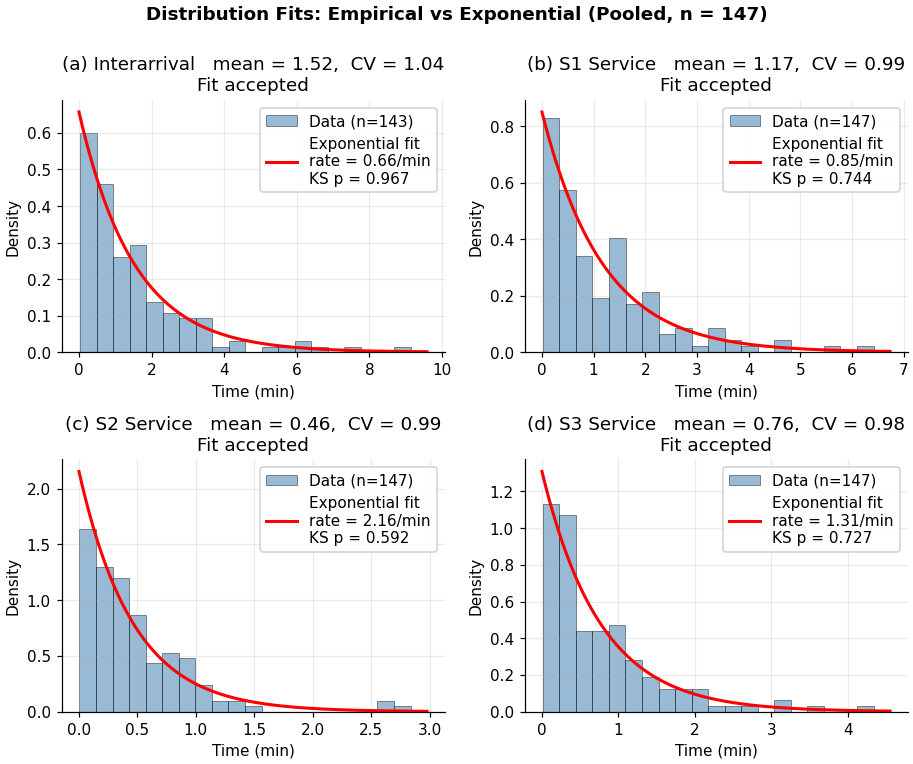

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8.5, 7.0))
axes = axes.flatten()

for i, (name, s) in enumerate(samples_pooled.items()):
    ax = axes[i]
    s = s[s > 0]
    mean = s.mean()
    cv = s.std() / mean
    _, ks_p = stats.kstest(s, 'expon', args=(0, mean))

    ax.hist(s, bins=20, density=True, alpha=0.55, color='steelblue',
            edgecolor='black', linewidth=0.5, label=f'Data (n={len(s)})')
    x_grid = np.linspace(0.001, s.max() * 1.05, 200)
    ax.plot(x_grid, stats.expon.pdf(x_grid, 0, mean), 'r-', lw=2.0,
            label=f'Exponential fit\nrate = {1/mean:.2f}/min\nKS p = {ks_p:.3f}')

    verdict = 'Fit accepted' if ks_p > 0.05 else 'Fit rejected'
    ax.set_title(f'({chr(97+i)}) {name}   mean = {mean:.2f},  CV = {cv:.2f}\n{verdict}')
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Density')
    ax.legend(loc='best', frameon=True, framealpha=0.9)

fig.suptitle('Distribution Fits: Empirical vs Exponential (Pooled, n = 147)',
             fontsize=12, fontweight='bold', y=1.00)
fig.tight_layout()
save_fig(fig, 'distribution-fits')
plt.show()


**Validation takeaway:** all four pooled samples fail to reject the exponential model at the 0.05 level, and all CV values are close to 1. This supports the Markovian assumptions used in the paper.


## 5. Parameter Estimation

For an exponential sample, the maximum-likelihood estimate of the rate is the reciprocal of the sample mean. We estimate $\lambda$, $\mu_1$, $\mu_2$, and $\mu_3$ for each day and for the pooled dataset.


In [7]:
def estimate_params(df):
    """Estimate one day's lambda and stage service rates from sample means."""
    interarr = df['Interarrival (min)'].dropna()
    return {
        'lambda': 1.0 / interarr.mean(),
        'mu1': 1.0 / df['_svc1_corrected'].mean(),
        'mu2': 1.0 / df['_svc2_corrected'].mean(),
        'mu3': 1.0 / df['_svc3_corrected'].mean(),
        'n': len(df),
    }

params = {name: estimate_params(df) for name, df in dfs.items()}
params['Pooled'] = {
    'lambda': 1.0 / np.mean(pooled_interarr),
    'mu1': 1.0 / np.mean(pooled_s1),
    'mu2': 1.0 / np.mean(pooled_s2),
    'mu3': 1.0 / np.mean(pooled_s3),
    'n': sum(len(df) for df in dfs.values()),
}

param_df = pd.DataFrame(params).T
param_df['rho1'] = param_df['lambda'] / param_df['mu1']
param_df['rho2'] = param_df['lambda'] / param_df['mu2']
param_df['rho3'] = param_df['lambda'] / param_df['mu3']

print('PARAMETER ESTIMATES USED IN THE PAPER MODEL')
print('=' * 85)
print(param_df.round(3).to_string())


PARAMETER ESTIMATES USED IN THE PAPER MODEL
        lambda    mu1    mu2    mu3      n   rho1   rho2   rho3
Day 1    0.585  0.833  2.142  1.130   50.0  0.702  0.273  0.517
Day 2    0.609  0.863  2.045  1.519   44.0  0.706  0.298  0.401
Day 3    0.825  0.860  2.279  1.360   53.0  0.958  0.362  0.606
Pooled   0.662  0.852  2.158  1.310  147.0  0.778  0.307  0.505


**Bottleneck preview:** Stage 1 has the highest utilization in every scenario. In the pooled data, `rho1 = 0.778`, much higher than Stage 2 (`0.307`) and Stage 3 (`0.505`).


## 6. Analytic Tandem Queue Results

Using the estimates above, we compute steady-state metrics for each M/M/1 stage and sum the stage-level quantities for the full tandem network.


In [8]:
def mm1_metrics(lam, mu):
    """Standard M/M/1 steady-state metrics for one service stage."""
    if lam >= mu:
        return {'rho': lam/mu, 'L': np.inf, 'Lq': np.inf, 'W': np.inf, 'Wq': np.inf}
    rho = lam / mu
    return {
        'rho': rho,
        'L': rho / (1-rho),
        'Lq': rho**2 / (1-rho),
        'W': 1 / (mu-lam),
        'Wq': rho / (mu-lam),
    }

def mmc_metrics(lam, mu, c):
    """M/M/c steady-state metrics using the Erlang-C formula."""
    a = lam / mu
    rho = lam / (c * mu)
    if rho >= 1:
        return {'rho': rho, 'L': np.inf, 'Lq': np.inf, 'W': np.inf, 'Wq': np.inf}

    sum_terms = sum((a**k) / math.factorial(k) for k in range(c))
    last_term = (a**c) / math.factorial(c) * (1 / (1-rho))
    P0 = 1.0 / (sum_terms + last_term)
    erlang_c = last_term * P0
    Lq = erlang_c * rho / (1-rho)
    Wq = Lq / lam
    W = Wq + 1 / mu

    return {'rho': rho, 'L': lam * W, 'Lq': Lq, 'W': W, 'Wq': Wq, 'P(wait)': erlang_c}

def tandem_analytic(lam, mus, servers=None):
    """Analyze a three-stage tandem network stage by stage."""
    if servers is None:
        servers = [1] * len(mus)

    results = {}
    for i, (mu, c) in enumerate(zip(mus, servers), start=1):
        results[f'Stage {i}'] = mm1_metrics(lam, mu) if c == 1 else mmc_metrics(lam, mu, c)

    results['System'] = {
        'W':  sum(results[f'Stage {i}']['W']  for i in range(1, len(mus)+1)),
        'Wq': sum(results[f'Stage {i}']['Wq'] for i in range(1, len(mus)+1)),
        'L':  sum(results[f'Stage {i}']['L']  for i in range(1, len(mus)+1)),
        'Lq': sum(results[f'Stage {i}']['Lq'] for i in range(1, len(mus)+1)),
    }
    return results

base_analytic = {}
for name, p in params.items():
    base_analytic[name] = tandem_analytic(p['lambda'], [p['mu1'], p['mu2'], p['mu3']])

for name in ['Day 1', 'Day 2', 'Day 3', 'Pooled']:
    p = params[name]
    print(f"\n{name} - lambda={p['lambda']:.3f}, mus=({p['mu1']:.2f}, {p['mu2']:.2f}, {p['mu3']:.2f})")
    print(f"{'Stage':<10} {'rho':<8} {'L':<8} {'Lq':<8} {'W':<10} {'Wq':<10}")
    for stage in ['Stage 1', 'Stage 2', 'Stage 3', 'System']:
        m = base_analytic[name][stage]
        rho_text = f"{m.get('rho', float('nan')):.3f}" if 'rho' in m else '-'
        print(f"{stage:<10} {rho_text:<8} {m['L']:<8.3f} {m['Lq']:<8.3f} {m['W']:<10.3f} {m['Wq']:<10.3f}")


Day 1 - lambda=0.585, mus=(0.83, 2.14, 1.13)
Stage      rho      L        Lq       W          Wq        
Stage 1    0.702    2.356    1.654    4.027      2.827     
Stage 2    0.273    0.376    0.103    0.642      0.175     
Stage 3    0.517    1.072    0.555    1.833      0.949     
System     -        3.804    2.311    6.502      3.951     

Day 2 - lambda=0.609, mus=(0.86, 2.04, 1.52)
Stage      rho      L        Lq       W          Wq        
Stage 1    0.706    2.398    1.692    3.935      2.777     
Stage 2    0.298    0.424    0.126    0.697      0.208     
Stage 3    0.401    0.670    0.269    1.100      0.441     
System     -        3.492    2.087    5.731      3.426     

Day 3 - lambda=0.825, mus=(0.86, 2.28, 1.36)
Stage      rho      L        Lq       W          Wq        
Stage 1    0.958    23.063   22.104   27.971     26.808    
Stage 2    0.362    0.567    0.205    0.688      0.249     
Stage 3    0.606    1.541    0.935    1.869      1.133     
System     -        25.

**Analytic takeaway:** the pooled expected system time is 7.49 minutes. Stage 1 contributes 5.28 of those minutes, so order taking is the dominant source of congestion.


## 7. Discrete-Event Simulation Validation

The simulation moves individual customers through the same three-stage system. This is a check on the formulas and a second way to estimate system time.


In [9]:
def simulate_tandem(lam, mus, servers=None, n_customers=20000, warmup_fraction=0.2, seed=1):
    """Discrete-event simulation for a tandem queue."""
    if servers is None:
        servers = [1] * len(mus)

    rng = np.random.default_rng(seed)
    n_stages = len(mus)
    arrivals = np.cumsum(rng.exponential(1/lam, size=n_customers))
    service_times = [rng.exponential(1/mus[i], size=n_customers) for i in range(n_stages)]

    server_free = [np.zeros(servers[i]) for i in range(n_stages)]
    stage_end = np.zeros((n_stages, n_customers))

    for customer in range(n_customers):
        for stage in range(n_stages):
            entry_time = arrivals[customer] if stage == 0 else stage_end[stage-1, customer]
            server_index = np.argmin(server_free[stage])
            start_time = max(entry_time, server_free[stage][server_index])
            end_time = start_time + service_times[stage][customer]
            server_free[stage][server_index] = end_time
            stage_end[stage, customer] = end_time

    warmup = int(n_customers * warmup_fraction)
    system_times = (stage_end[-1] - arrivals)[warmup:]
    return {'W_sys': system_times.mean(), 'std': system_times.std()}

des_base = {}
for name, p in params.items():
    replications = []
    for rep in range(10):
        result = simulate_tandem(p['lambda'], [p['mu1'], p['mu2'], p['mu3']], seed=rep*7 + 1)
        replications.append(result['W_sys'])
    des_base[name] = {'W_sys': np.mean(replications), 'std': np.std(replications)}

print('THREE-WAY COMPARISON: Observed vs DES vs Analytic')
print('=' * 80)
print(f"{'Scenario':<10} {'Observed W':<18} {'DES W':<20} {'Analytic W':<15}")
print('-' * 80)
for name in ['Day 1', 'Day 2', 'Day 3', 'Pooled']:
    combined = pd.concat(list(dfs.values()), ignore_index=True) if name == 'Pooled' else dfs[name]
    obs_W = combined['Total Sys (min)'].mean()
    obs_sem = combined['Total Sys (min)'].std() / np.sqrt(len(combined))
    des_W = des_base[name]['W_sys']
    des_sd = des_base[name]['std']
    an_W = base_analytic[name]['System']['W']
    print(f"{name:<10} {f'{obs_W:.3f} +/- {obs_sem:.3f}':<18} {f'{des_W:.3f} +/- {des_sd:.3f}':<20} {an_W:<15.3f}")


THREE-WAY COMPARISON: Observed vs DES vs Analytic
Scenario   Observed W         DES W                Analytic W     
--------------------------------------------------------------------------------
Day 1      5.177 +/- 0.422    6.473 +/- 0.147      6.502          
Day 2      4.802 +/- 0.447    5.700 +/- 0.152      5.731          
Day 3      8.843 +/- 0.621    29.931 +/- 12.038    30.527         
Pooled     6.387 +/- 0.333    7.445 +/- 0.234      7.490          


**Simulation takeaway:** for the pooled case, analytic and DES estimates are nearly identical (`7.490` vs. `7.445` minutes). Observed times are lower because the observation windows are finite lunch periods, not long-run steady-state experiments.


## 8. Figures for the Paper

These figures are saved into `Figures/` and are the same visual story used in the paper: model/data comparison and utilization-based bottleneck identification.


  saved: Figures/comparison.png
  saved: Figures/utilization.png


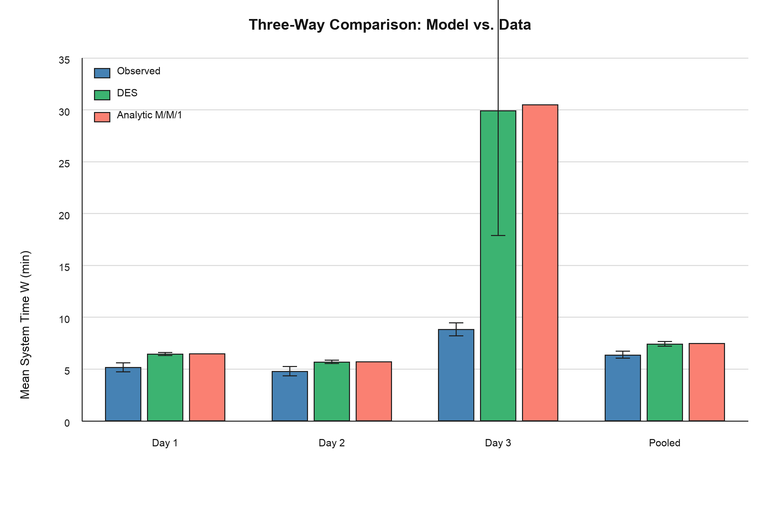

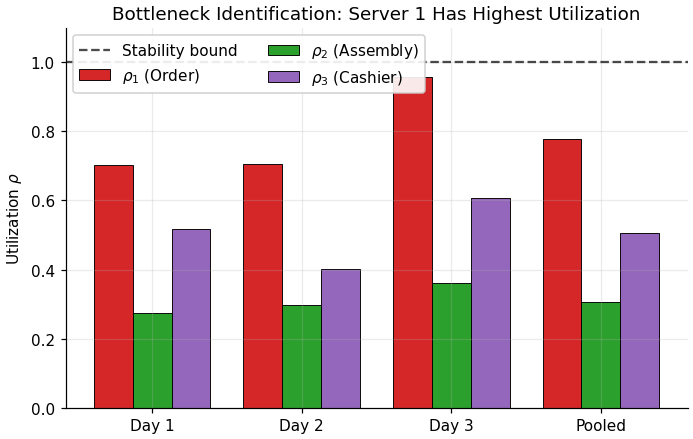

In [10]:
scenarios = ['Day 1', 'Day 2', 'Day 3', 'Pooled']
x = np.arange(len(scenarios))

obs_W, obs_sem, des_W, des_sd, an_W = [], [], [], [], []
for name in scenarios:
    combined = pd.concat(list(dfs.values()), ignore_index=True) if name == 'Pooled' else dfs[name]
    obs_W.append(combined['Total Sys (min)'].mean())
    obs_sem.append(combined['Total Sys (min)'].std() / np.sqrt(len(combined)))
    des_W.append(des_base[name]['W_sys'])
    des_sd.append(des_base[name]['std'])
    an_W.append(base_analytic[name]['System']['W'])

fig2, ax = plt.subplots(figsize=(6.5, 4.2))
w = 0.26
ax.bar(x - w, obs_W, w, yerr=obs_sem, label='Observed',
       color='steelblue', capsize=4, edgecolor='black', linewidth=0.6)
ax.bar(x, des_W, w, yerr=des_sd, label='DES',
       color='mediumseagreen', capsize=4, edgecolor='black', linewidth=0.6)
ax.bar(x + w, an_W, w, label='Analytic M/M/1',
       color='salmon', edgecolor='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('Mean System Time W (min)')
ax.set_title('Three-Way Comparison: Model vs. Data')
ax.set_ylim(0, min(max(an_W) * 1.15, 35))
ax.legend(loc='upper left', frameon=True, framealpha=0.9)
fig2.tight_layout()
save_fig(fig2, 'comparison')
plt.show()

fig3, ax = plt.subplots(figsize=(6.5, 4.2))
rho1s = [base_analytic[s]['Stage 1']['rho'] for s in scenarios]
rho2s = [base_analytic[s]['Stage 2']['rho'] for s in scenarios]
rho3s = [base_analytic[s]['Stage 3']['rho'] for s in scenarios]

ax.bar(x - w, rho1s, w, label='rho1 (Order)', color='#d62728', edgecolor='black', linewidth=0.6)
ax.bar(x, rho2s, w, label='rho2 (Assembly)', color='#2ca02c', edgecolor='black', linewidth=0.6)
ax.bar(x + w, rho3s, w, label='rho3 (Cashier)', color='#9467bd', edgecolor='black', linewidth=0.6)
ax.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Stability bound')
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('Utilization rho')
ax.set_title('Bottleneck Identification: Server 1 Has Highest Utilization')
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left', ncol=2, frameon=True, framealpha=0.9)
fig3.tight_layout()
save_fig(fig3, 'utilization')
plt.show()


## 9. Improvement: Add a Second Order-Taker

Since Stage 1 is the bottleneck, the proposed improvement is to staff two parallel order-takers during peak demand. That changes Stage 1 from M/M/1 to M/M/2 while leaving Stage 2 and Stage 3 as M/M/1.

For M/M/c, define $a=\lambda/\mu$ and $\rho=\lambda/(c\mu)$. Erlang-C gives the probability an arrival waits:

$$C(c,a)=\frac{\frac{a^c}{c!}\frac{1}{1-\rho}}{\sum_{k=0}^{c-1}\frac{a^k}{k!}+\frac{a^c}{c!}\frac{1}{1-\rho}}.$$

Then:

$$L_q=C(c,a)\frac{\rho}{1-\rho}, \quad W_q=\frac{L_q}{\lambda}, \quad W=W_q+\frac{1}{\mu}.$$


In [11]:
improved_analytic = {}
for name, p in params.items():
    improved_analytic[name] = tandem_analytic(p['lambda'], [p['mu1'], p['mu2'], p['mu3']], servers=[2, 1, 1])

des_improved = {}
for name, p in params.items():
    replications = []
    for rep in range(10):
        result = simulate_tandem(p['lambda'], [p['mu1'], p['mu2'], p['mu3']], servers=[2, 1, 1], seed=rep*7 + 1)
        replications.append(result['W_sys'])
    des_improved[name] = {'W_sys': np.mean(replications), 'std': np.std(replications)}

print('IMPROVEMENT RESULTS: Parallel Server 1 (M/M/2 at Stage 1)')
print('=' * 100)
print(f"{'Scenario':<10} {'Base W (Analyt)':<17} {'Base W (DES)':<17} {'Improved W (Analyt)':<20} {'Improved W (DES)':<18} {'% Reduction':<12}")
print('-' * 100)
for name in ['Day 1', 'Day 2', 'Day 3', 'Pooled']:
    b_an = base_analytic[name]['System']['W']
    i_an = improved_analytic[name]['System']['W']
    b_ds = f"{des_base[name]['W_sys']:.2f}+/-{des_base[name]['std']:.2f}"
    i_ds = f"{des_improved[name]['W_sys']:.2f}+/-{des_improved[name]['std']:.2f}"
    pct = (b_an - i_an) / b_an * 100
    print(f"{name:<10} {b_an:<17.3f} {b_ds:<17} {i_an:<20.3f} {i_ds:<18} {pct:<12.1f}%")

print('\nSTAGE-LEVEL BREAKDOWN (Pooled):')
print(f"{'Stage':<15} {'Base W':<12} {'Improved W':<14} {'% Reduction':<12}")
for stage in ['Stage 1', 'Stage 2', 'Stage 3', 'System']:
    b = base_analytic['Pooled'][stage]['W']
    i = improved_analytic['Pooled'][stage]['W']
    pct = (b - i) / b * 100
    print(f"{stage:<15} {b:<12.3f} {i:<14.3f} {pct:<12.1f}%")


IMPROVEMENT RESULTS: Parallel Server 1 (M/M/2 at Stage 1)
Scenario   Base W (Analyt)   Base W (DES)      Improved W (Analyt)  Improved W (DES)   % Reduction 
----------------------------------------------------------------------------------------------------
Day 1      6.502             6.47+/-0.15       3.844                4.47+/-0.04        40.9        %
Day 2      5.731             5.70+/-0.15       3.119                3.68+/-0.03        45.6        %
Day 3      30.527            29.93+/-12.04     4.065                4.86+/-0.06        86.7        %
Pooled     7.490             7.45+/-0.23       3.595                4.24+/-0.04        52.0        %

STAGE-LEVEL BREAKDOWN (Pooled):
Stage           Base W       Improved W     % Reduction 
Stage 1         5.278        1.383          73.8        %
Stage 2         0.669        0.669          0.0         %
Stage 3         1.543        1.543          0.0         %
System          7.490        3.595          52.0        %


**Improvement takeaway:** in the pooled scenario, the analytic system time drops from 7.49 minutes to 3.60 minutes, a 52% reduction. Stage 1 alone drops by about 74%.


## 10. Sensitivity Analysis

The last check asks whether the proposed improvement still helps as demand changes. This matters because the most valuable staffing changes are the ones that protect the system during busier periods.


  saved: Figures/impact.png
  saved: Figures/sensitivity.png


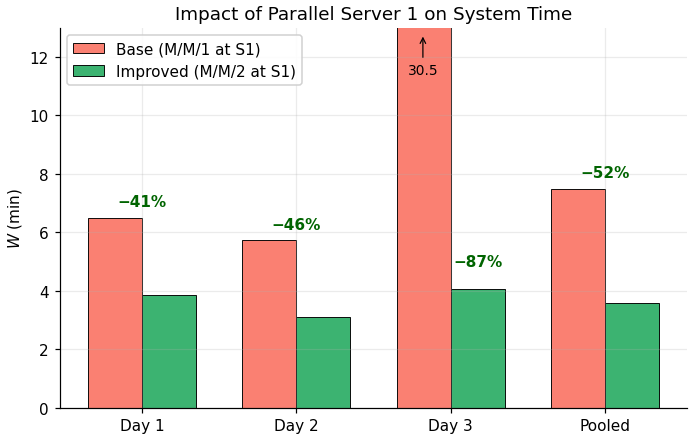

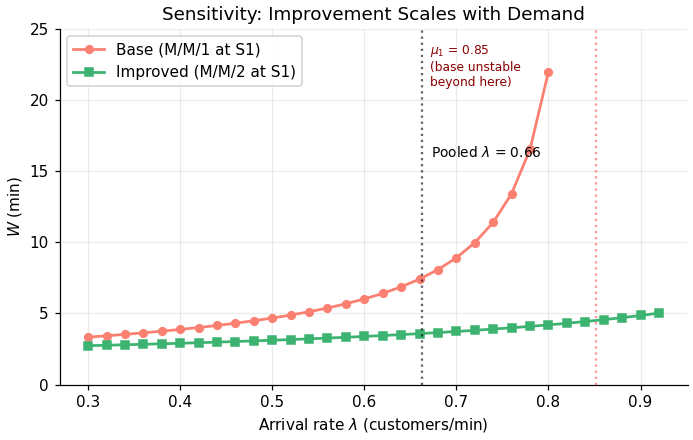

In [12]:
def mmc_W(lam, mu, c):
    a = lam / mu
    rho = lam / (c * mu)
    if rho >= 1:
        return np.inf
    if c == 1:
        return 1 / (mu - lam)
    sum_terms = sum((a ** k) / math.factorial(k) for k in range(c))
    last_term = (a ** c) / math.factorial(c) * (1 / (1 - rho))
    P0 = 1.0 / (sum_terms + last_term)
    erlang_c = last_term * P0
    Lq = erlang_c * rho / (1 - rho)
    return Lq / lam + 1 / mu

lams = np.arange(0.30, 0.92, 0.02)
p = params['Pooled']
mus = [p['mu1'], p['mu2'], p['mu3']]

base_W_curve = [sum(mmc_W(lam, mus[i], 1) for i in range(3)) for lam in lams]
imp_W_curve = [sum(mmc_W(lam, mus[i], 2 if i == 0 else 1) for i in range(3)) for lam in lams]

scenarios = ['Day 1', 'Day 2', 'Day 3', 'Pooled']
x = np.arange(len(scenarios))
base_an = [base_analytic[s]['System']['W'] for s in scenarios]
imp_an = [improved_analytic[s]['System']['W'] for s in scenarios]

fig4, ax = plt.subplots(figsize=(6.5, 4.2))
w = 0.35
ax.bar(x - w/2, base_an, w, label='Base (M/M/1 at S1)', color='salmon', edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, imp_an, w, label='Improved (M/M/2 at S1)', color='mediumseagreen', edgecolor='black', linewidth=0.6)

YMAX = 13
for i in range(len(scenarios)):
    pct = (base_an[i] - imp_an[i]) / base_an[i] * 100
    y = max(base_an[i], imp_an[i])
    if y > YMAX - 0.5:
        ax.text(i + 0.18, imp_an[i] + 0.8, f'-{pct:.0f}%', ha='center', fontsize=10, fontweight='bold', color='darkgreen')
        ax.annotate(f'{base_an[i]:.1f}', xy=(i - 0.18, YMAX - 0.2), xytext=(i - 0.18, YMAX - 1.6),
                    ha='center', fontsize=9, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
    else:
        ax.text(i, y + 0.4, f'-{pct:.0f}%', ha='center', fontsize=10, fontweight='bold', color='darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.set_ylabel('W (min)')
ax.set_title('Impact of Parallel Server 1 on System Time')
ax.set_ylim(0, YMAX)
ax.legend(loc='upper left', frameon=True, framealpha=0.9)
fig4.tight_layout()
save_fig(fig4, 'impact')
plt.show()

fig5, ax = plt.subplots(figsize=(6.5, 4.2))
valid = [(lam, b) for lam, b in zip(lams, base_W_curve) if np.isfinite(b) and b < 30]
if valid:
    lv, bv = zip(*valid)
    ax.plot(lv, bv, 'o-', color='salmon', lw=1.8, markersize=5, label='Base (M/M/1 at S1)')
ax.plot(lams, imp_W_curve, 's-', color='mediumseagreen', lw=1.8, markersize=5, label='Improved (M/M/2 at S1)')
ax.axvline(p['lambda'], color='black', linestyle=':', alpha=0.6)
ax.text(p['lambda'] + 0.01, 16, f"Pooled lambda = {p['lambda']:.2f}", fontsize=9)
ax.axvline(mus[0], color='red', linestyle=':', alpha=0.4)
ax.text(mus[0] - 0.18, 21, f"mu1 = {mus[0]:.2f}\n(base unstable\nbeyond here)", fontsize=8, color='darkred')
ax.set_xlabel('Arrival rate lambda (customers/min)')
ax.set_ylabel('W (min)')
ax.set_title('Sensitivity: Improvement Scales with Demand')
ax.set_ylim(0, 25)
ax.legend(loc='upper left', frameon=True, framealpha=0.9)
fig5.tight_layout()
save_fig(fig5, 'sensitivity')
plt.show()


## 11. Final Takeaways and Limitations

### Main findings

1. Roots is better modeled as a three-stage tandem queue than as an M/M/3 queue, because workers are specialized and customers move through the stages in sequence.
2. The pooled model estimates `lambda = 0.662` arrivals/min, `mu1 = 0.852`, `mu2 = 2.158`, and `mu3 = 1.310` services/min.
3. Stage 1 is the bottleneck: pooled `rho1 = 0.778`, compared with `rho2 = 0.307` and `rho3 = 0.505`.
4. The analytic tandem model and DES agree closely for the pooled case: 7.49 minutes vs. 7.45 minutes.
5. Adding a second order-taker reduces pooled analytic system time from 7.49 to 3.60 minutes, or about 52%.

### Limitations

- Batch arrivals were treated as single arrival units because it was difficult to track every individual in the venue.
- The lunch period is not truly stationary; arrival rates probably rise and fall over the window.
- Some timestamps were cleaned after collection to correct obvious entry mistakes.
- The timestamp schema can mix service time with blocking time, especially when one stage waits for downstream capacity.
- A future version should collect group IDs, individual service completions, and enough observations to model time-varying arrival rates.

These limitations are important, but the bottleneck result is still consistent across the analytic model, simulation, and utilization plots. 

*AI was used in improving our data visualization and manipulation skills but not our base methodologies, code drafts, or math work.*
